# PHÁT HIỆN GIAN LẬN TRONG GIAO DỊCH

# 1. XÁC ĐỊNH BÀI TOÁN

Trong bài toán Classification, biến phản hồi nhận giá trị 1 nếu giao dịch đó là gian lận và 0 nếu ngược lại.

Tập dữ liệu này chứa các giao dịch được thực hiện bằng thẻ tín dụng trong tháng 9 năm 2013 bởi những người dùng thẻ ở châu Âu, đồng thời thể hiện các giao dịch xảy ra trong hai ngày, trong đó có 492 trường hợp gian lận trên tổng số 284.807 giao dịch. Tập dữ liệu này rất mất cân bằng, lớp gian lận chỉ chiếm 0,172% tổng số giao dịch. Nhiệm vụ là dự báo gian lận. Biến 'Class' là biến phản hồi và nó nhận giá trị 1 trong trường hợp gian lận và 0 trong trường hợp ngược lại.

Mục tiêu của bài toán này là sử dụng các mô hình phân loại khác nhau để phát hiện xem một giao dịch là thanh toán hợp lệ hay gian lận.

# 2. DOWNLOAD PACKAGE VÀ DATASET

In [29]:
import numpy as np
import pandas as pd
from matplotlib import pyplot
from pandas import read_csv, set_option
from pandas.plotting import scatter_matrix
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier, RandomForestClassifier, ExtraTreesClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from keras.models import Sequential
from scikeras.wrappers import KerasClassifier
from keras.layers import Dense
from keras.optimizers import SGD

from pickle import dump
from pickle import load

In [30]:
import warnings
warnings.filterwarnings('ignore')

In [31]:
dataset = read_csv('creditcard.csv', encoding='utf-8')

# 3. TIỀN XỬ LÝ DỮ LIỆU

## 3.1. Mô tả dữ liệu

In [32]:
dataset.shape

(284807, 31)

In [33]:
set_option('display.width', 100)
dataset.head(5)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.360,-0.073,2.536,1.378,-0.338,0.462,0.240,0.099,0.364,...,-0.018,0.278,-0.110,0.067,0.129,-0.189,0.134,-0.021,149.62,0
1,0.0,1.192,0.266,0.166,0.448,0.060,-0.082,-0.079,0.085,-0.255,...,-0.226,-0.639,0.101,-0.340,0.167,0.126,-0.009,0.015,2.69,0
2,1.0,-1.358,-1.340,1.773,0.380,-0.503,1.800,0.791,0.248,-1.515,...,0.248,0.772,0.909,-0.689,-0.328,-0.139,-0.055,-0.060,378.66,0
3,1.0,-0.966,-0.185,1.793,-0.863,-0.010,1.247,0.238,0.377,-1.387,...,-0.108,0.005,-0.190,-1.176,0.647,-0.222,0.063,0.061,123.50,0
4,2.0,-1.158,0.878,1.549,0.403,-0.407,0.096,0.593,-0.271,0.818,...,-0.009,0.798,-0.137,0.141,-0.206,0.502,0.219,0.215,69.99,0


In [34]:
set_option('display.max_rows', 500)
dataset.dtypes

Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

Như kết quả ở trên cho thấy, toàn bộ dữ liệu đều có kiểu dữ liệu float, ngoại trừ Class có kiểu dữ liệu integer và tên biến không được trực quan cho lắm.

In [35]:
pd.set_option('display.precision', 3)
dataset.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000,2.848e+05,2.848e+05,2.848e+05,2.848e+05,2.848e+05,2.848e+05,2.848e+05,2.848e+05,2.848e+05,...,2.848e+05,2.848e+05,2.848e+05,2.848e+05,2.848e+05,2.848e+05,2.848e+05,2.848e+05,284807.000,284807.000
mean,94813.860,1.168e-15,3.417e-16,-1.380e-15,2.074e-15,9.604e-16,1.487e-15,-5.556e-16,1.213e-16,-2.406e-15,...,1.654e-16,-3.569e-16,2.579e-16,4.473e-15,5.341e-16,1.683e-15,-3.660e-16,-1.227e-16,88.350,0.002
std,47488.146,1.959e+00,1.651e+00,1.516e+00,1.416e+00,1.380e+00,1.332e+00,1.237e+00,1.194e+00,1.099e+00,...,7.345e-01,7.257e-01,6.245e-01,6.056e-01,5.213e-01,4.822e-01,4.036e-01,3.301e-01,250.120,0.042
min,0.000,-5.641e+01,-7.272e+01,-4.833e+01,-5.683e+00,-1.137e+02,-2.616e+01,-4.356e+01,-7.322e+01,-1.343e+01,...,-3.483e+01,-1.093e+01,-4.481e+01,-2.837e+00,-1.030e+01,-2.605e+00,-2.257e+01,-1.543e+01,0.000,0.000
25%,54201.500,-9.204e-01,-5.985e-01,-8.904e-01,-8.486e-01,-6.916e-01,-7.683e-01,-5.541e-01,-2.086e-01,-6.431e-01,...,-2.284e-01,-5.424e-01,-1.618e-01,-3.546e-01,-3.171e-01,-3.270e-01,-7.084e-02,-5.296e-02,5.600,0.000
50%,84692.000,1.811e-02,6.549e-02,1.798e-01,-1.985e-02,-5.434e-02,-2.742e-01,4.010e-02,2.236e-02,-5.143e-02,...,-2.945e-02,6.782e-03,-1.119e-02,4.098e-02,1.659e-02,-5.214e-02,1.342e-03,1.124e-02,22.000,0.000
75%,139320.500,1.316e+00,8.037e-01,1.027e+00,7.433e-01,6.119e-01,3.986e-01,5.704e-01,3.273e-01,5.971e-01,...,1.864e-01,5.286e-01,1.476e-01,4.395e-01,3.507e-01,2.410e-01,9.105e-02,7.828e-02,77.165,0.000
max,172792.000,2.455e+00,2.206e+01,9.383e+00,1.688e+01,3.480e+01,7.330e+01,1.206e+02,2.001e+01,1.559e+01,...,2.720e+01,1.050e+01,2.253e+01,4.585e+00,7.520e+00,3.517e+00,3.161e+01,3.385e+01,25691.160,1.000


Bây giờ nhóm sẽ kiểm tra số lượng trường hợp gian lận so với trường hợp không gian lận trong tập dữ liệu.

In [36]:
class_names = {0:'Not Fraud', 1:'Fraud'}
print(dataset.Class.value_counts().rename(index = class_names))

Class
Not Fraud    284315
Fraud           492
Name: count, dtype: int64


Bộ dữ liệu không cân bằng, với phần lớn các giao dịch không phải là gian lận.

## 3.2. Trực quan hoá dữ liệu

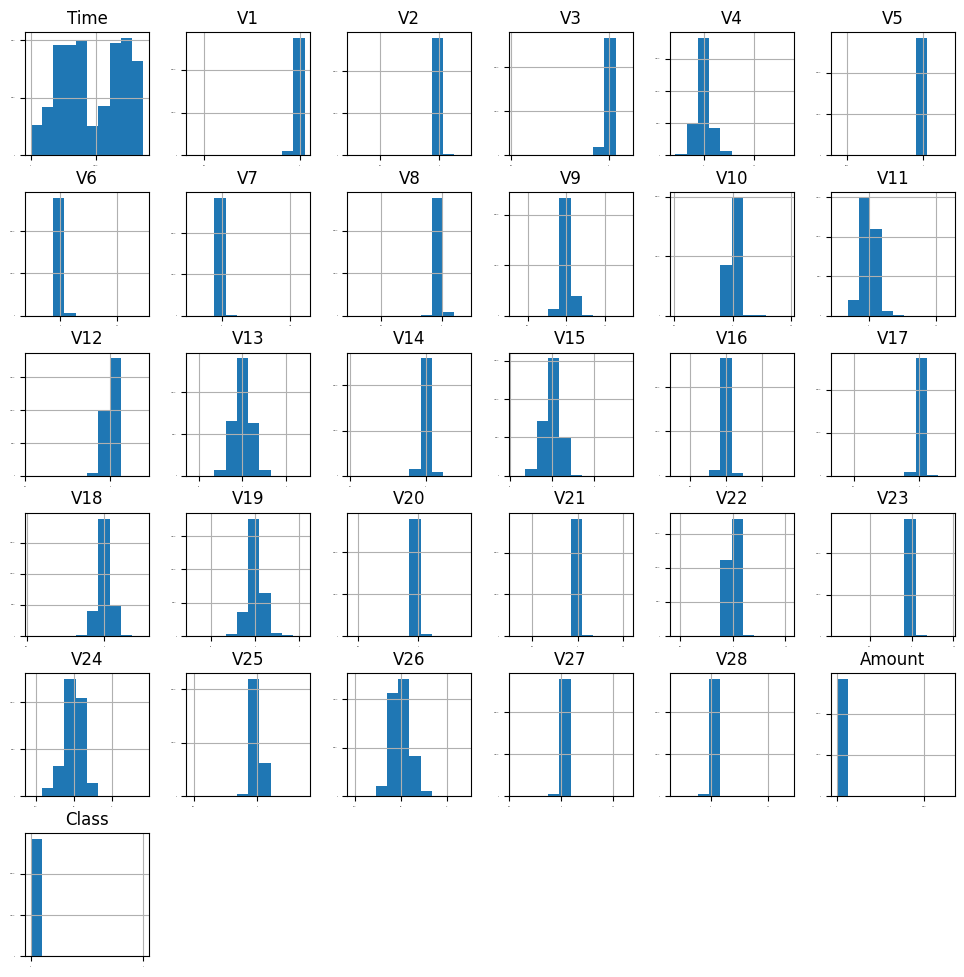

In [37]:
dataset.hist(sharex=False, sharey=False, xlabelsize=1, ylabelsize=1, figsize=(12,12))
pyplot.show()

Phân bố của hầu hết các biến đều bị lệch mạnh. Tuy nhiên, do tên các biến không được biết tên nên không thể hiểu rõ ý nghĩa của các biểu đồ.

# 4. CHUẨN BỊ DỮ LIỆU

In [38]:
print('Null Values =',dataset.isnull().values.any())

Null Values = False


Dữ liệu không chứa giá trị null và đã ở định dạng số thực, do đó không cần phải làm sạch hoặc phân loại dữ liệu.

In [39]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2

bestfeatures = SelectKBest( k=10)
bestfeatures
Y= dataset["Class"]
X = dataset.loc[:, dataset.columns != 'Class']
fit = bestfeatures.fit(X,Y)
dfscores = pd.DataFrame(fit.scores_)
dfcolumns = pd.DataFrame(X.columns)
featureScores = pd.concat([dfcolumns,dfscores],axis=1)
featureScores.columns = ['Specs','Score']
print(featureScores.nlargest(10,'Score'))

   Specs      Score
17   V17  33979.169
14   V14  28695.548
12   V12  20749.822
10   V10  14057.980
16   V16  11443.349
3     V3  11014.508
7     V7  10349.605
11   V11   6999.355
4     V4   5163.832
18   V18   3584.381


Mặc dù một vài đặc trưng là liên quan, nhưng việc lựa chọn các đặc trưng không được ưu tiên đáng kể.

# 5. ĐÁNH GIÁ CÁC MÔ HÌNH VÀ THUẬT TOÁN

## 5.1. Chia tập dữ liệu huấn luyện, kiểm thử

In [40]:
Y= dataset["Class"]
X = dataset.loc[:, dataset.columns != 'Class']
validation_size = 0.2
num_folds = 10
seed = 7
X_train, X_validation, Y_train, Y_validation = train_test_split(X, Y, test_size=validation_size, random_state=seed)

## 5.2. Điều chỉnh cân bằng dữ liệu bằng Random Under Sampling

Nhóm sẽ thực hiện phương pháp Random Under Sampling, về cơ bản bao gồm việc loại bỏ dữ liệu để có được tập dữ liệu cân bằng hơn, từ đó tránh được hiện tượng overfitting cho mô hình.

Các bước:
1. Việc đầu tiên cần làm là xác định mức độ mất cân bằng của Class (sử dụng hàm "value_counts()" trên cột Class để xác định số lượng cho mỗi nhãn).
2. Sau khi xác định được số lượng giao dịch được coi là gian lận (Gian lận = "1"), nhóm sẽ đưa số lượng giao dịch không gian lận về cùng mức với giao dịch gian lận (giả sử tỷ lệ là 50/50), điều này sẽ tương đương với 492 trường hợp gian lận và 492 trường hợp giao dịch không gian lận.
3. Sau khi áp dụng kỹ thuật này, nhóm có một tập dữ liệu con của dataframe với tỷ lệ 50/50 giữa các lớp. Bước tiếp theo sẽ thực hiện là xáo trộn dữ liệu để xem liệu mô hình có thể duy trì độ chính xác nhất định mỗi khi chạy đoạn mã này hay không.

In [41]:
Y_train.head()

44828     0
221877    0
278826    0
149792    0
226041    0
Name: Class, dtype: int64

In [42]:
df = pd.concat([X_train, Y_train], axis=1)
fraud_df = df.loc[df['Class'] == 1]
non_fraud_df = df.loc[df['Class'] == 0][:492]

normal_distributed_df = pd.concat([fraud_df, non_fraud_df])

df_new = normal_distributed_df.sample(frac=1, random_state=42)
Y_train_new= df_new["Class"]
X_train_new = df_new.loc[:, dataset.columns != 'Class']

dataset.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.360,-0.073,2.536,1.378,-0.338,0.462,0.240,0.099,0.364,...,-0.018,0.278,-0.110,0.067,0.129,-0.189,0.134,-0.021,149.62,0
1,0.0,1.192,0.266,0.166,0.448,0.060,-0.082,-0.079,0.085,-0.255,...,-0.226,-0.639,0.101,-0.340,0.167,0.126,-0.009,0.015,2.69,0
2,1.0,-1.358,-1.340,1.773,0.380,-0.503,1.800,0.791,0.248,-1.515,...,0.248,0.772,0.909,-0.689,-0.328,-0.139,-0.055,-0.060,378.66,0
3,1.0,-0.966,-0.185,1.793,-0.863,-0.010,1.247,0.238,0.377,-1.387,...,-0.108,0.005,-0.190,-1.176,0.647,-0.222,0.063,0.061,123.50,0
4,2.0,-1.158,0.878,1.549,0.403,-0.407,0.096,0.593,-0.271,0.818,...,-0.009,0.798,-0.137,0.141,-0.206,0.502,0.219,0.215,69.99,0


Phân bố các Class trong tập dữ liệu mẫu con
Class
0    0.557
1    0.443
Name: count, dtype: float64


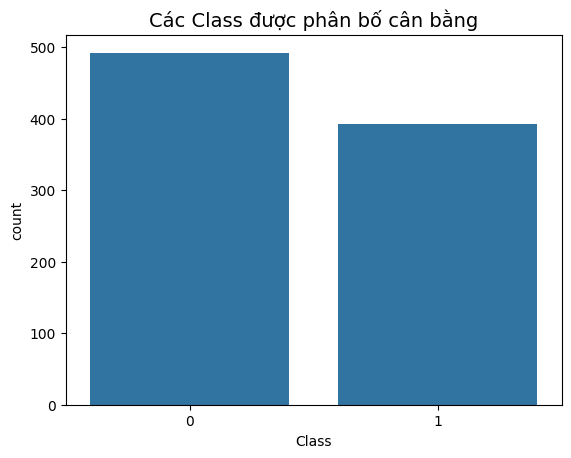

In [43]:
print('Phân bố các Class trong tập dữ liệu mẫu con')
print(df_new['Class'].value_counts()/len(df_new))
sns.countplot(x='Class', data=df_new)
pyplot.title('Các Class được phân bố cân bằng', fontsize=14)
pyplot.show()

Bây giờ khi DataFrame đã được cân bằng, tiếp tục thực hiện các bước phân tích và tiền xử lý dữ liệu sâu hơn.
Do tổng số điểm dữ liệu chỉ khoảng 900, nhóm tiến hành thử nghiệm tất cả các mô hình, bao gồm cả các mô hình học sâu.
Tuy nhiên, vì dữ liệu đã được cân bằng, chỉ số đánh giá được sử dụng là Recall, vì nó đo lường khả năng nhận diện chính xác các mẫu thuộc lớp dương tính của mô hình và đặc biệt nhạy cảm với các trường hợp âm tính giả.